# 📘 Feature Scaling — Complete Guide

Feature scaling is a **preprocessing technique** used to transform the values of features (columns) so that they fall within a similar range or distribution. Many machine learning algorithms (e.g., KNN, SVM, Gradient Descent–based models) are **sensitive to the scale** of input features.

---

## Why Feature Scaling?

| Problem without scaling | Explanation |
|---|---|
| **Distance-based algorithms break** | KNN, K-Means use Euclidean distance — a feature with large values dominates |
| **Gradient Descent converges slowly** | Unscaled features cause elongated contours → zig-zag updates |
| **Regularization is unfair** | L1/L2 penalties affect large-valued features differently |
| **PCA misdirected** | Principal components align with the highest-variance (largest-scale) feature |

---

## When is scaling NOT needed?

- **Tree-based models** (Decision Trees, Random Forest, XGBoost) — they split on thresholds, not distances.
- **Naive Bayes** — works with probabilities, not raw distances.

---

## Three Main Techniques Covered

| # | Technique | Class in sklearn | Key Idea |
|---|---|---|---|
| 1 | **Standardization** (Z-score) | `StandardScaler` | Centers to mean=0, std=1 |
| 2 | **Normalization** (Min-Max) | `MinMaxScaler` | Rescales to [0, 1] |
| 3 | **Robust Scaling** | `RobustScaler` | Uses median & IQR — resistant to outliers |

In [3]:
# ── Imports ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

import warnings
warnings.filterwarnings('ignore')

print("✅ All imports loaded successfully")

✅ All imports loaded successfully


---

## 📊 Step 1: Create a Sample Dataset

We'll create a dataset with features at **very different scales** to clearly see the effect of scaling.

| Feature | Range | Unit |
|---|---|---|
| Age | 18–65 | years |
| Salary | 15,000–150,000 | NPR/month |
| Experience | 0–40 | years |
| Spending Score | 1–100 | score |

We also inject **outliers** in Salary and Experience to demonstrate the advantage of Robust Scaling.

In [4]:
# ── Create Sample Dataset ────────────────────────────────
np.random.seed(42)

n = 30  # number of samples

data = {
    'Age':            np.random.randint(18, 66, n),
    'Salary':         np.random.randint(15000, 150001, n),
    'Experience':     np.random.randint(0, 41, n),
    'Spending_Score': np.random.randint(1, 101, n),
}

df = pd.DataFrame(data)

# ── Inject outliers ──
df.loc[0, 'Salary']     = 900000    # extreme high salary
df.loc[1, 'Salary']     = 500       # extreme low salary
df.loc[2, 'Experience'] = 80        # impossible experience

print(f"Shape: {df.shape}")
df.head(10)

Shape: (30, 4)


,Age,Salary,Experience,Spending_Score
0,56,900000,35,71
1,46,500,39,9
2,32,145523,80,88
3,60,17747,1,1
4,25,138855,5,8
5,38,80725,3,88
6,56,144981,28,63
7,36,99654,17,11
8,40,134346,25,81
9,28,82435,33,8


In [7]:
# ── Basic Statistics (notice the huge range differences) ──
df.describe().round(2)

,Age,Salary,Experience,Spending_Score
count,30.00,30.00,30.00,30.00
mean,41.37,112466.10,22.60,44.10
std,12.64,155192.39,15.80,30.48
min,19.00,500.00,0.00,1.00
25%,33.00,52341.50,13.25,14.75
50%,41.00,83620.00,22.50,36.00
75%,52.25,133563.50,29.50,71.75
max,61.00,900000.00,80.00,99.00


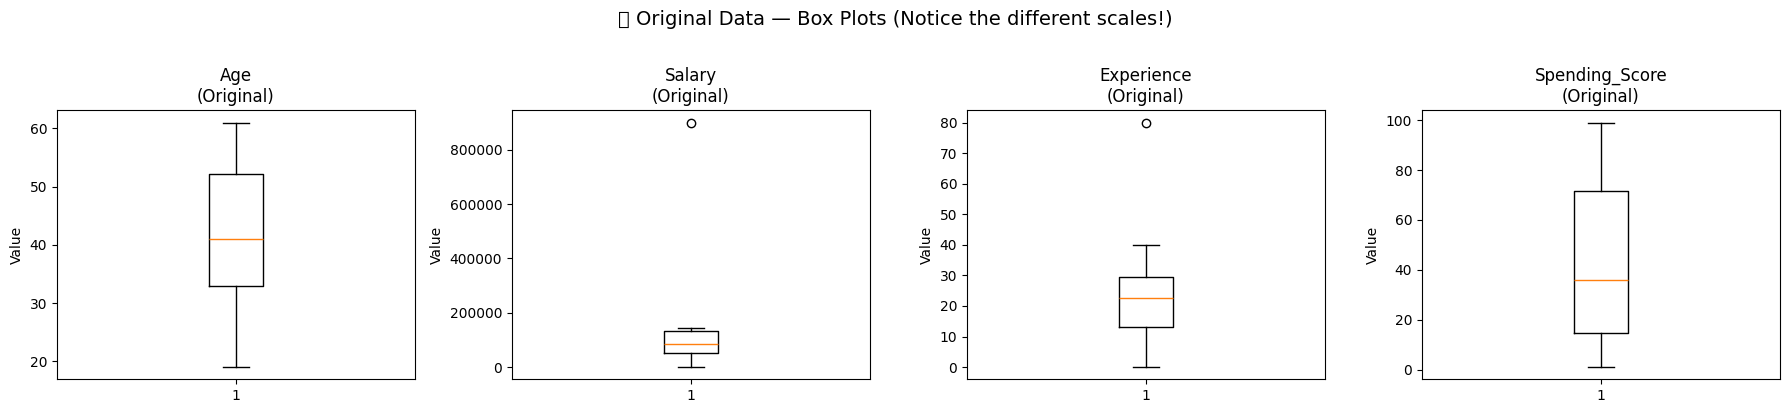

In [ ]:
# ── Visualize original distributions ─────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for i, col in enumerate(df.columns):
    axes[i].boxplot(df[col], vert=True)
    axes[i].set_title(f'{col}\n(Original)', fontsize=12)
    axes[i].set_ylabel('Value')
fig.suptitle("Original Data — Box Plots (Notice the different scales!)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

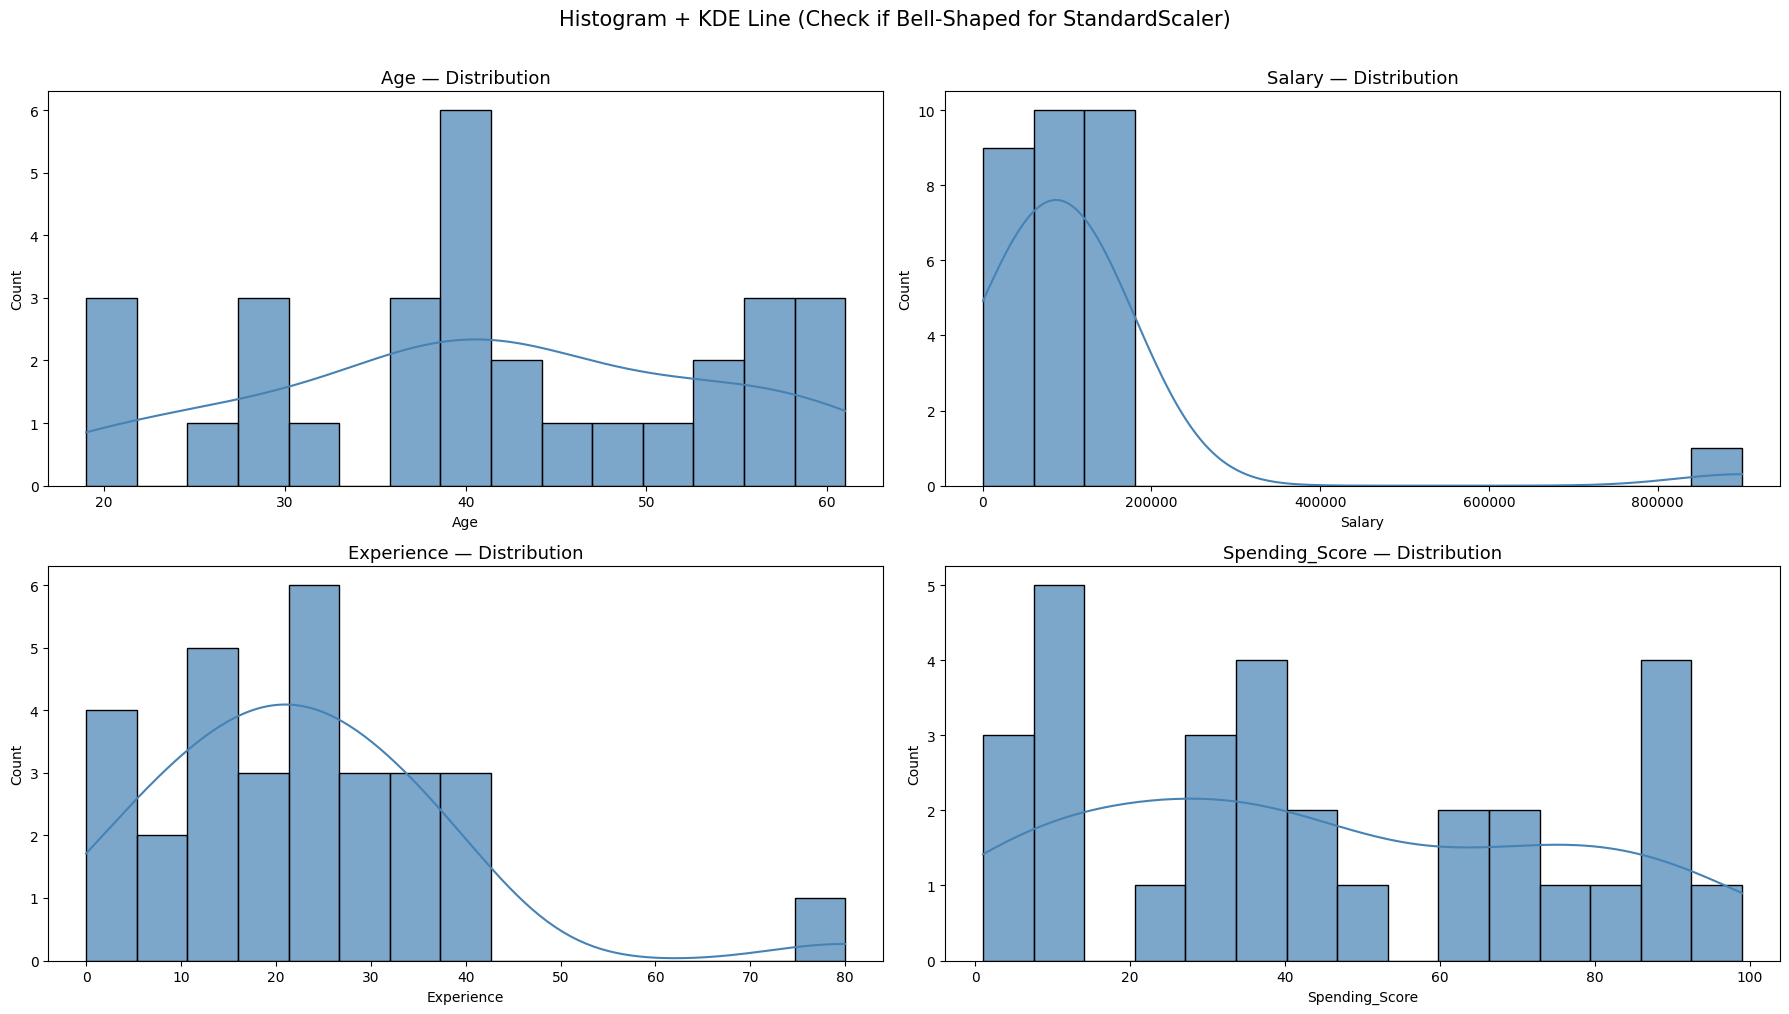

In [25]:
# Also see the distribution of the data using histograms

# If bell-shaped → use StandardScaler | If not → use MinMaxScaler or RobustScaler

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()  

# axes[0] → Age
sns.histplot(df['Age'], bins=15, kde=True, color='steelblue', edgecolor='black', alpha=0.7, ax=axes[0])
axes[0].set_title('Age — Distribution', fontsize=13)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

# axes[1] → Salary
sns.histplot(df['Salary'], bins=15, kde=True, color='steelblue', edgecolor='black', alpha=0.7, ax=axes[1])
axes[1].set_title('Salary — Distribution', fontsize=13)
axes[1].set_xlabel('Salary')
axes[1].set_ylabel('Count')

# axes[2] → Experience
sns.histplot(df['Experience'], bins=15, kde=True, color='steelblue', edgecolor='black', alpha=0.7, ax=axes[2])
axes[2].set_title('Experience — Distribution', fontsize=13)
axes[2].set_xlabel('Experience')
axes[2].set_ylabel('Count')

# axes[3] → Spending_Score
sns.histplot(df['Spending_Score'], bins=15, kde=True, color='steelblue', edgecolor='black', alpha=0.7, ax=axes[3])
axes[3].set_title('Spending_Score — Distribution', fontsize=13)
axes[3].set_xlabel('Spending_Score')
axes[3].set_ylabel('Count')

fig.suptitle("Histogram + KDE Line (Check if Bell-Shaped for StandardScaler)", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

---

# 1️⃣ Standardization (Z-Score Scaling)

## Formula

$$X_{scaled} = \frac{X - \mu}{\sigma}$$

Where:
- $\mu$ = mean of the feature
- $\sigma$ = standard deviation of the feature

## Key Properties

| Property | Detail |
|---|---|
| **Mean after scaling** | 0 |
| **Std after scaling** | 1 |
| **Handles outliers?** | ❌ 
| **Best for** | Algorithms assuming normally distributed features (Logistic Regression, SVM, PCA, Neural Nets) |
| **sklearn class** | `StandardScaler()` |

## When to Use
- Data is **approximately Gaussian** (bell-shaped)
- Algorithm uses **gradient descent** or **distance calculations**
- You want features on the **same scale without bounding** them to [0,1]

## When NOT to Use
- Data has **heavy outliers** → use RobustScaler instead
- You need values strictly in **[0, 1]** → use MinMaxScaler

In [9]:
# ══════════════════════════════════════════════════════════
#  1) STANDARDIZATION  (StandardScaler)
# ══════════════════════════════════════════════════════════

scaler_standard = StandardScaler()

# fit_transform learns mean & std, then transforms
df_standard = pd.DataFrame(
    scaler_standard.fit_transform(df),
    columns=df.columns
)

print("── After StandardScaler ──")
print(f"Means  : {df_standard.mean().round(6).values}")   # ≈ 0
print(f"Stds   : {df_standard.std().round(2).values}")     # ≈ 1
print()
df_standard.head(10)

── After StandardScaler ──
Means  : [-0. -0. -0. -0.]
Stds   : [1.02 1.02 1.02 1.02]



,Age,Salary,Experience,Spending_Score
0,1.177282,5.161316,0.798247,0.897520
1,0.372761,-0.733800,1.055745,-1.171113
2,-0.753568,0.216647,3.695109,1.464725
3,1.499091,-0.620767,-1.390494,-1.438033
4,-1.316733,0.172947,-1.132995,-1.204478
5,-0.270855,-0.208024,-1.261744,1.464725
6,1.177282,0.213095,0.347623,0.630599
7,-0.431760,-0.083968,-0.360498,-1.104383
8,-0.109951,0.143396,0.154499,1.231170
9,-1.075376,-0.196817,0.669497,-1.204478


In [10]:
# ── Manual verification of StandardScaler for 'Age' column ──
age_mean = df['Age'].mean()
age_std  = df['Age'].std(ddof=0)  # sklearn uses population std (ddof=0)

manual_z = (df['Age'] - age_mean) / age_std
sklearn_z = df_standard['Age']

print(f"Age Mean  = {age_mean:.2f}")
print(f"Age Std   = {age_std:.2f}")
print(f"\nManual Z-scores match sklearn? → {np.allclose(manual_z.values, sklearn_z.values)}")
print()

# Show side by side
pd.DataFrame({
    'Age_Original': df['Age'],
    'Manual_Z': manual_z.round(4),
    'Sklearn_Z': sklearn_z.round(4)
}).head(10)

Age Mean  = 41.37
Age Std   = 12.43

Manual Z-scores match sklearn? → True



,Age_Original,Manual_Z,Sklearn_Z
0,56,1.1773,1.1773
1,46,0.3728,0.3728
2,32,-0.7536,-0.7536
3,60,1.4991,1.4991
4,25,-1.3167,-1.3167
5,38,-0.2709,-0.2709
6,56,1.1773,1.1773
7,36,-0.4318,-0.4318
8,40,-0.1100,-0.1100
9,28,-1.0754,-1.0754


---

# 2️⃣ Normalization (Min-Max Scaling)

## Formula

$$X_{scaled} = \frac{X - X_{min}}{X_{max} - X_{min}}$$

This maps every value to the **[0, 1]** range.

## Key Properties

| Property | Detail |
|---|---|
| **Min after scaling** | 0 |
| **Max after scaling** | 1 |
| **Handles outliers?** | ❌ 
| **Best for** | Neural Networks (sigmoid/tanh activations), image pixel data, algorithms needing bounded input |
| **sklearn class** | `MinMaxScaler()` |

## When to Use
- Data does **not** follow a Gaussian distribution
- Algorithm requires input in **[0, 1]** (Neural Networks, image processing)
- Features already have a **known bounded range**

## When NOT to Use
- Data has **significant outliers** → min/max get distorted
- You need a **normal-like distribution** → use StandardScaler

## ⚠️ Outlier Problem Illustrated
If Salary ranges from 500 to 900,000 but most values are 15K–150K:
- The outlier 900,000 becomes 1.0
- ALL other values get squeezed into a tiny range near 0
- **Information is lost!**

In [11]:
# ══════════════════════════════════════════════════════════
#  2) NORMALIZATION  (MinMaxScaler)
# ══════════════════════════════════════════════════════════

scaler_minmax = MinMaxScaler()

df_minmax = pd.DataFrame(
    scaler_minmax.fit_transform(df),
    columns=df.columns
)

print("── After MinMaxScaler ──")
print(f"Min values : {df_minmax.min().values}")   # all 0.0
print(f"Max values : {df_minmax.max().values}")    # all 1.0
print()
df_minmax.head(10)

── After MinMaxScaler ──
Min values : [0. 0. 0. 0.]
Max values : [1. 1. 1. 1.]



,Age,Salary,Experience,Spending_Score
0,0.880952,1.000000,0.4375,0.714286
1,0.642857,0.000000,0.4875,0.081633
2,0.309524,0.161226,1.0000,0.887755
3,0.976190,0.019174,0.0125,0.000000
4,0.142857,0.153813,0.0625,0.071429
5,0.452381,0.089188,0.0375,0.887755
6,0.880952,0.160624,0.3500,0.632653
7,0.404762,0.110232,0.2125,0.102041
8,0.500000,0.148800,0.3125,0.816327
9,0.214286,0.091089,0.4125,0.071429


In [12]:
# ── Manual verification of MinMaxScaler for 'Salary' column ──
sal_min = df['Salary'].min()
sal_max = df['Salary'].max()

manual_minmax = (df['Salary'] - sal_min) / (sal_max - sal_min)
sklearn_minmax = df_minmax['Salary']

print(f"Salary Min = {sal_min},  Salary Max = {sal_max}")
print(f"\nManual Min-Max matches sklearn? → {np.allclose(manual_minmax.values, sklearn_minmax.values)}")
print()

# ⚠️ See how outlier compresses all normal salaries near 0
print("⚠️  Outlier Effect on Salary (MinMax):")
print(f"   Original salary row 0 (outlier 900K) → scaled = {sklearn_minmax.iloc[0]:.4f}")
print(f"   Original salary row 3 (normal)       → scaled = {sklearn_minmax.iloc[3]:.4f}")
print(f"   Most normal salaries are squeezed near 0!")

Salary Min = 500,  Salary Max = 900000

Manual Min-Max matches sklearn? → True

⚠️  Outlier Effect on Salary (MinMax):
   Original salary row 0 (outlier 900K) → scaled = 1.0000
   Original salary row 3 (normal)       → scaled = 0.0192
   Most normal salaries are squeezed near 0!


---

# 3️⃣ Robust Scaling

## Formula

$$X_{scaled} = \frac{X - \text{median}}{IQR}$$

Where:
- $\text{median}$ = 50th percentile (Q2)
- $IQR$ = Interquartile Range = $Q3 - Q1$ (75th percentile – 25th percentile)

## Key Properties

| Property | Detail |
|---|---|
| **Center after scaling** | 0 (at the median) |
| **Handles outliers?** | ✅ **Yes!** 
| **Best for** | Data with **significant outliers** |
| **sklearn class** | `RobustScaler()` |

## Why is it Robust?
- **Mean** is pulled by outliers → StandardScaler gets distorted
- **Min/Max** are defined by outliers → MinMaxScaler compresses data
- **Median & IQR** are **not affected** by extreme values → RobustScaler stays stable

## When to Use
- Data has **outliers you can't/shouldn't remove**
- You want scaling that **ignores extreme values**
- Medical data, financial data, sensor data with spikes

## When NOT to Use
- Data is clean with no outliers → StandardScaler or MinMaxScaler are simpler
- You need output strictly in [0, 1]

In [13]:
# ══════════════════════════════════════════════════════════
#  3) ROBUST SCALING  (RobustScaler)
# ══════════════════════════════════════════════════════════

scaler_robust = RobustScaler()

df_robust = pd.DataFrame(
    scaler_robust.fit_transform(df),
    columns=df.columns
)

print("── After RobustScaler ──")
print(f"Medians (should be ≈ 0): {df_robust.median().round(4).values}")
print()
df_robust.head(10)

── After RobustScaler ──
Medians (should be ≈ 0): [0. 0. 0. 0.]



,Age,Salary,Experience,Spending_Score
0,0.779221,10.051218,0.769231,0.614035
1,0.259740,-1.023368,1.015385,-0.473684
2,-0.467532,0.762146,3.538462,0.912281
3,0.987013,-0.811024,-1.323077,-0.614035
4,-0.831169,0.680050,-1.076923,-0.491228
5,-0.155844,-0.035643,-1.200000,0.912281
6,0.779221,0.755473,0.338462,0.473684
7,-0.259740,0.197410,-0.338462,-0.438596
8,-0.051948,0.624535,0.153846,0.789474
9,-0.675325,-0.014590,0.646154,-0.491228


In [14]:
# ── Manual verification of RobustScaler for 'Salary' column ──
sal_median = df['Salary'].median()
sal_q1     = df['Salary'].quantile(0.25)
sal_q3     = df['Salary'].quantile(0.75)
sal_iqr    = sal_q3 - sal_q1

manual_robust = (df['Salary'] - sal_median) / sal_iqr
sklearn_robust = df_robust['Salary']

print(f"Salary Median = {sal_median}")
print(f"Salary Q1 = {sal_q1},  Q3 = {sal_q3},  IQR = {sal_iqr}")
print(f"\nManual Robust matches sklearn? → {np.allclose(manual_robust.values, sklearn_robust.values)}")
print()

# Compare how Salary outlier is treated
print("🔍 Outlier Handling Comparison for Salary row 0 (900,000):")
print(f"   StandardScaler → {df_standard['Salary'].iloc[0]:.4f}")
print(f"   MinMaxScaler   → {df_minmax['Salary'].iloc[0]:.4f}")
print(f"   RobustScaler   → {df_robust['Salary'].iloc[0]:.4f}")
print(f"\n   RobustScaler keeps the outlier as a large number but does NOT distort other values.")

Salary Median = 83620.0
Salary Q1 = 52341.5,  Q3 = 133563.5,  IQR = 81222.0

Manual Robust matches sklearn? → True

🔍 Outlier Handling Comparison for Salary row 0 (900,000):
   StandardScaler → 5.1613
   MinMaxScaler   → 1.0000
   RobustScaler   → 10.0512

   RobustScaler keeps the outlier as a large number but does NOT distort other values.


---

# Visual Comparison — All Three Scalers Side by Side

The plots below show how each scaler transforms the same data. Pay special attention to the **Salary** column (which has outliers).

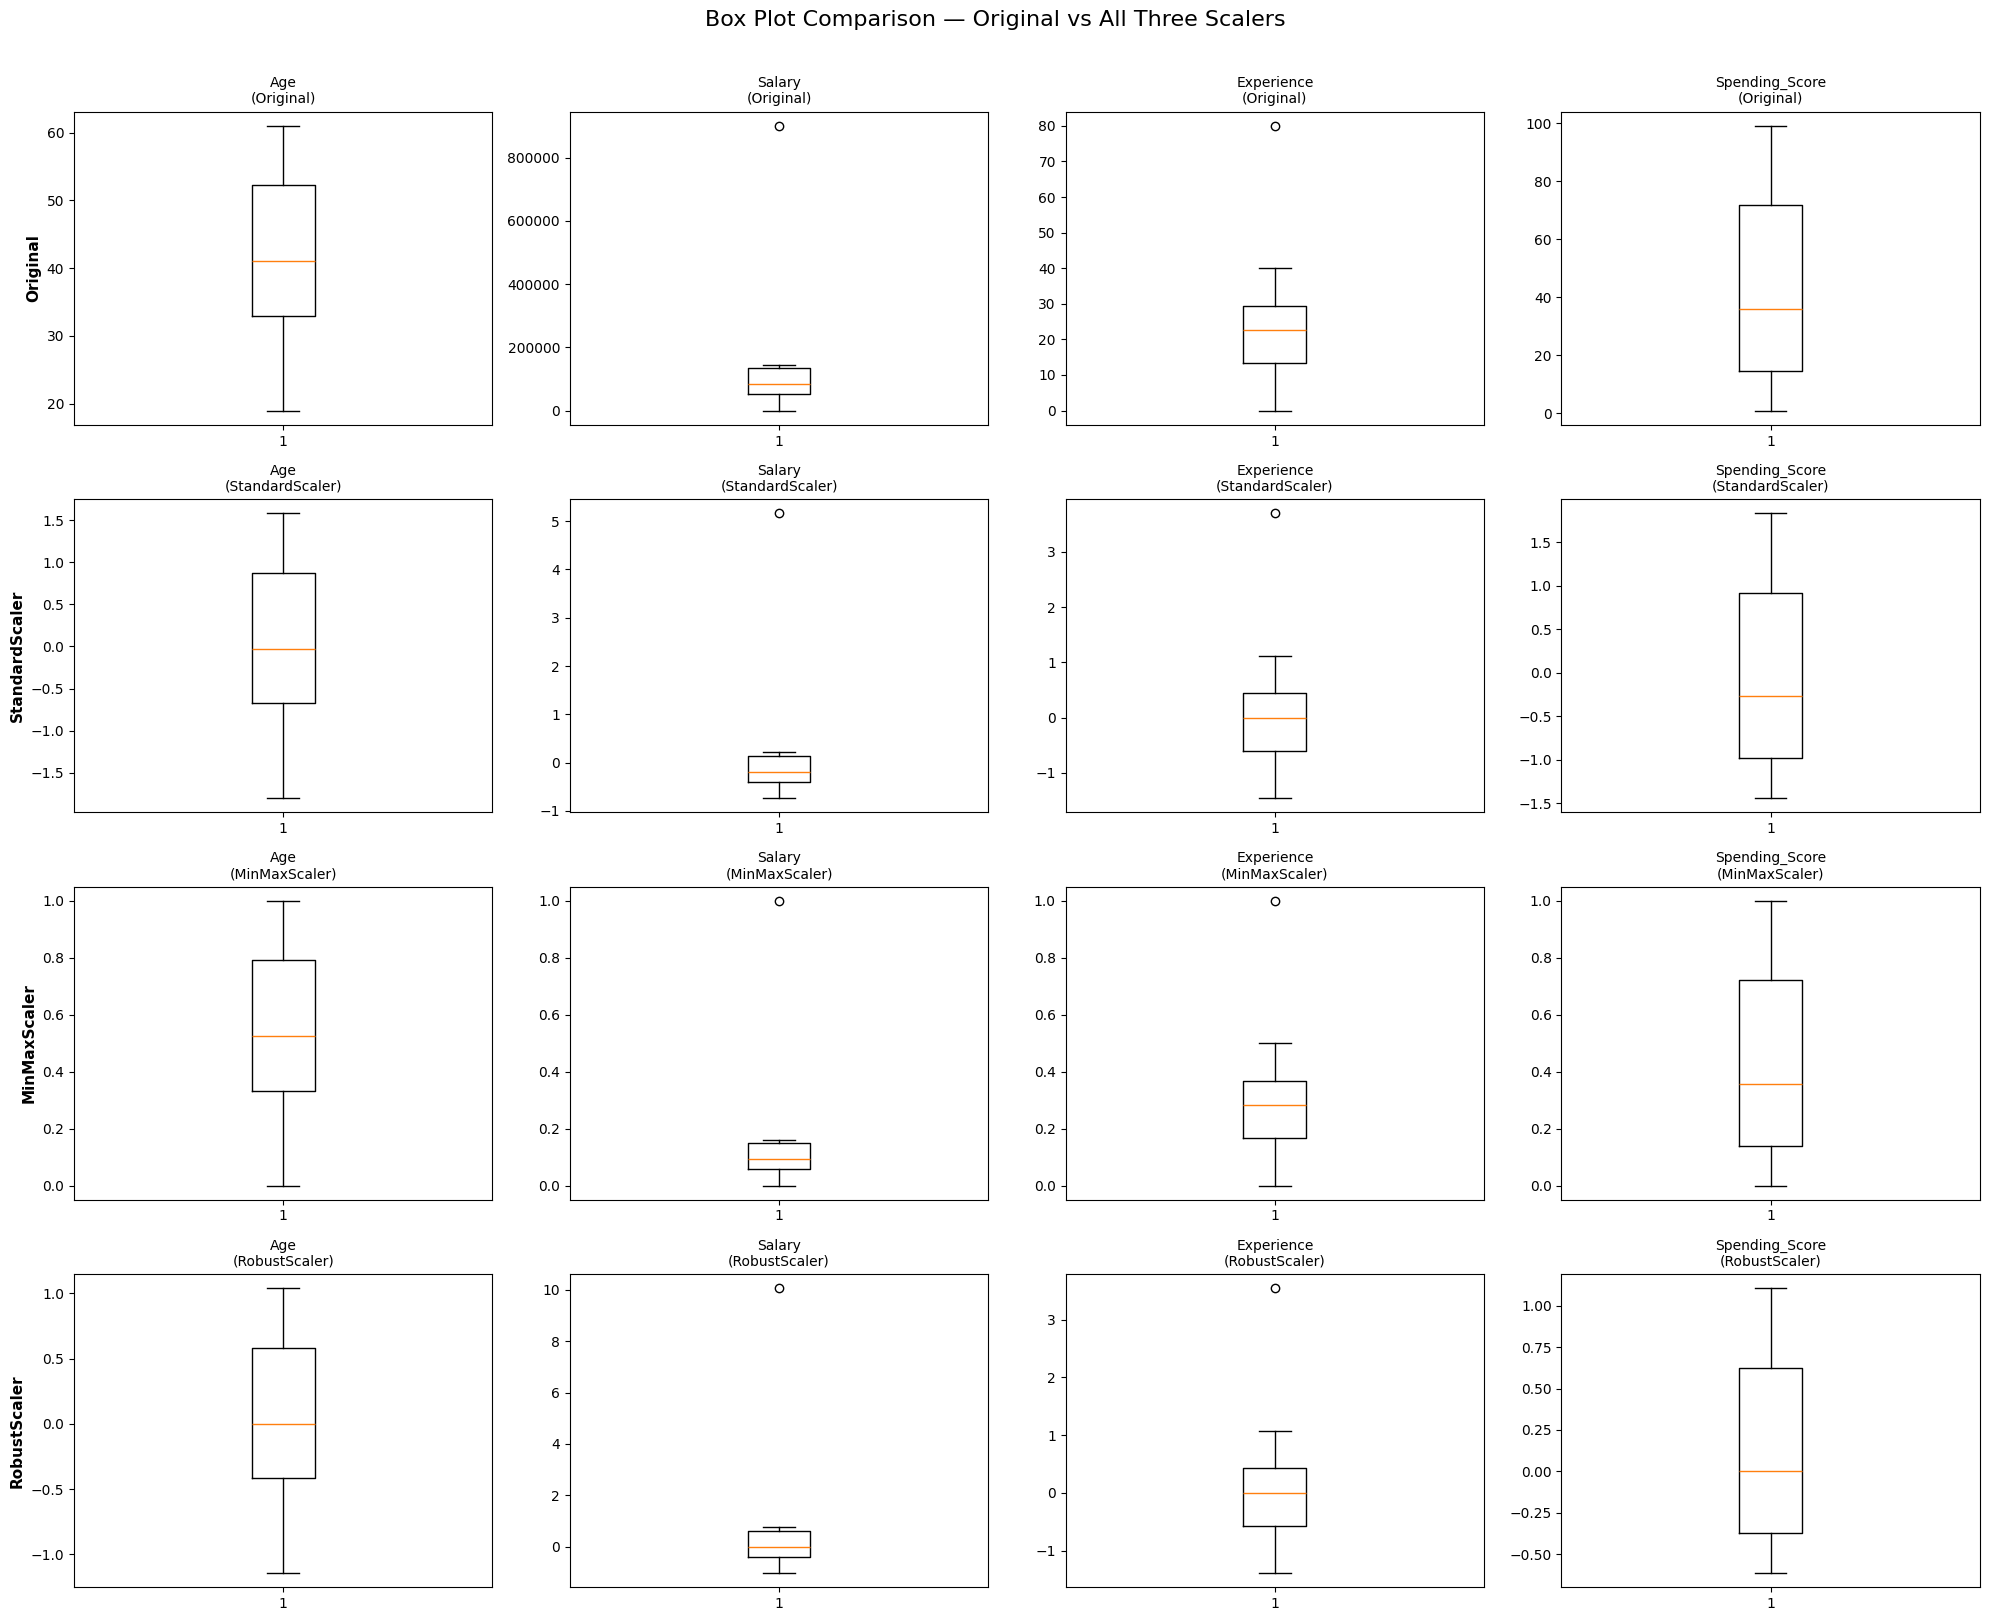

In [15]:
# ══════════════════════════════════════════════════════════
#  VISUAL COMPARISON — Box Plots for all 4 versions
# ══════════════════════════════════════════════════════════

datasets = {
    'Original':       df,
    'StandardScaler': df_standard,
    'MinMaxScaler':   df_minmax,
    'RobustScaler':   df_robust,
}

fig, axes = plt.subplots(4, 4, figsize=(20, 16))

for row, (name, data) in enumerate(datasets.items()):
    for col, feature in enumerate(df.columns):
        ax = axes[row][col]
        ax.boxplot(data[feature], vert=True)
        ax.set_title(f'{feature}\n({name})', fontsize=10)
        if col == 0:
            ax.set_ylabel(name, fontsize=11, fontweight='bold')

fig.suptitle("Box Plot Comparison — Original vs All Three Scalers", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

---

# Important: fit() vs transform() vs fit_transform()

Understanding these three methods is critical for **avoiding data leakage** in ML pipelines.

| Method | What it does |
|---|---|
| `fit(X_train)` | **Learns** the parameters (mean, std, min, max, median, IQR) from `X_train` only |
| `transform(X)` | **Applies** the learned parameters to transform data (can be train or test) |
| `fit_transform(X_train)` | Shortcut: `fit()` + `transform()` in one step — **use only on training data** |

##  Golden Rule

```python
# CORRECT ✅
scaler.fit(X_train)              # Learn from training data ONLY
X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)   # Use SAME parameters

# WRONG ❌  (causes data leakage!)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.fit_transform(X_test)  # Re-learns from test data!
```

In [17]:
# ══════════════════════════════════════════════════════════
#  DEMO: Correct Train/Test Scaling Workflow
# ══════════════════════════════════════════════════════════
from sklearn.model_selection import train_test_split

# Split data
X_train, X_test = train_test_split(df, test_size=0.3, random_state=42)

print(f"Train shape: {X_train.shape}")
print(f"Test shape:  {X_test.shape}")
print()

# ── CORRECT approach ──
scaler = StandardScaler()

# Step 1: fit ONLY on training data
scaler.fit(X_train)

# Step 2: transform both using the SAME learned parameters
X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=df.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),  columns=df.columns, index=X_test.index)

print("── Learned from TRAINING data ──")
print(f"  Mean (from fit): {scaler.mean_.round(2)}")
print(f"  Std  (from fit): {scaler.scale_.round(2)}")
print()
print("── Train set after scaling ──")
print(f"  Mean: {X_train_scaled.mean().round(4).values}")
print(f"  Std:  {X_train_scaled.std().round(4).values}")
print()
print("── Test set after scaling (mean ≠ exactly 0 because we used TRAIN params) ──")
print(f"  Mean: {X_test_scaled.mean().round(4).values}")
print(f"  Std:  {X_test_scaled.std().round(4).values}")

Train shape: (21, 4)
Test shape:  (9, 4)

── Learned from TRAINING data ──
  Mean (from fit): [4.2380000e+01 1.2144919e+05 2.4520000e+01 4.1520000e+01]
  Std  (from fit): [1.1690000e+01 1.8042414e+05 1.7070000e+01 3.0200000e+01]

── Train set after scaling ──
  Mean: [ 0.  0. -0. -0.]
  Std:  [1.0247 1.0247 1.0247 1.0247]

── Test set after scaling (mean ≠ exactly 0 because we used TRAIN params) ──
  Mean: [-0.2893 -0.166  -0.3757  0.2844]
  Std:  [1.245  0.1879 0.6077 1.0029]


---

# Inverse Transform — Getting Original Values Back

All sklearn scalers support `inverse_transform()` to convert scaled values back to original scale. This is useful when you want to **interpret predictions** in the original units.

In [20]:
# ══════════════════════════════════════════════════════════
#  INVERSE TRANSFORM — Get Original Values Back
# ══════════════════════════════════════════════════════════

# Let's inverse-transform the StandardScaler output
df_back_from_standard = pd.DataFrame(
    scaler_standard.inverse_transform(df_standard),
    columns=df.columns
)

print("── Original Data (first 5 rows) ──")
print(df.head().to_string())
print()
print("── After inverse_transform of StandardScaler (first 5 rows) ──")
print(df_back_from_standard.head().round(2).to_string())
print()
print(f"✅ Values match original? → {np.allclose(df.values, df_back_from_standard.values)}")

── Original Data (first 5 rows) ──
   Age  Salary  Experience  Spending_Score
0   56  900000          35              71
1   46     500          39               9
2   32  145523          80              88
3   60   17747           1               1
4   25  138855           5               8

── After inverse_transform of StandardScaler (first 5 rows) ──
    Age    Salary  Experience  Spending_Score
0  56.0  900000.0        35.0            71.0
1  46.0     500.0        39.0             9.0
2  32.0  145523.0        80.0            88.0
3  60.0   17747.0         1.0             1.0
4  25.0  138855.0         5.0             8.0

✅ Values match original? → True


---

# Final Cheat Sheet — Which Scaler to Use?

```
                        ┌──────────────────────────┐
                        │   Does your data have    │
                        │   significant outliers?   │
                        └────────┬─────────────────┘
                                 │
                     ┌───────────┴───────────┐
                     │ YES                   │ NO
                     ▼                       ▼
              ┌──────────────┐    ┌─────────────────────────┐
              │ RobustScaler │    │ Is data roughly Gaussian │
              │              │    │ (bell-shaped)?           │
              └──────────────┘    └────────┬────────────────┘
                                           │
                                ┌──────────┴──────────┐
                                │ YES                 │ NO
                                ▼                     ▼
                        ┌────────────────┐    ┌──────────────┐
                        │ StandardScaler │    │ MinMaxScaler │
                        │ (Z-score)      │    │ ([0,1] range)│
                        └────────────────┘    └──────────────┘
```

## Quick Reference Table

| Criteria | StandardScaler | MinMaxScaler | RobustScaler |
|---|---|---|---|
| **Formula** | $(X - \mu) / \sigma$ | $(X - X_{min}) / (X_{max} - X_{min})$ | $(X - median) / IQR$ |
| **Centers to** | Mean = 0 | Min = 0 | Median = 0 |
| **Outlier resistant?** | ❌ | ❌ | ✅ |
| **Best algorithms** | SVM, Logistic Reg, PCA, Neural Nets | Neural Nets (sigmoid), KNN, image data | Any, when data has outliers |
| **sklearn class** | `StandardScaler()` | `MinMaxScaler()` | `RobustScaler()` |

---

## Key Takeaways

1. **Always scale features** for distance-based & gradient-based algorithms
2. **Never fit on test data** — always `fit()` on train, `transform()` on both
3. **StandardScaler** → default choice for Gaussian-like data
4. **MinMaxScaler** → when you need bounded [0,1] output
5. **RobustScaler** → when outliers exist and you can't remove them
6. **Tree-based models** don't need scaling (but it doesn't hurt)
7. Use `inverse_transform()` to convert predictions back to original scale